# Divide and Conquer

In [109]:
%run interface.ipynb
%run tests.ipynb

### Algorytm divide and conquer - wersja bez wizualizacji

In [77]:
def max_x_position(points):
    # znajduje punkt wysunięty najdalej na prawo
    maximal_x = points[0].x
    position = 0
    for i, point in enumerate(points):
        if point.x > maximal_x:
            maximal_x = point.x
            position = i
    
    return position

In [78]:
def min_x_position(points):
    # znajduje punkt wysunięty najdalej na lewo
    minimal_x = points[0].x
    position = 0
    for i, point in enumerate(points):
        if point.x < minimal_x:
            minimal_x = point.x
            position = i
    
    return position

In [79]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y
    
    if result > 10e-12:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-12:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [80]:
def set_hull(points, first, last):
    # Funkcja do ustawiania otoczki, kiedy zbiór punktów posiada mniej niż 3 punkty
    if last - first < 0:
        return []
    if last - first == 0:
        return [points[first]]
    if last - first == 1:
        return [points[first], points[last]]
    if last - first == 2:
        if orient(points[first], points[first + 1], points[last]) == 1:
            return [points[first], points[first + 1], points[last]]
        elif (points[first].x ==  points[first + 1].x and orient(points[first], points[first + 1], points[last]) != 0) or orient(points[first], points[first + 1], points[last]) == -1:
            return [points[first], points[last], points[first + 1]]
        else:
            return [points[first], points[last]]

In [81]:
def upper_section(left_hull, right_hull):
    len_l = len(left_hull)
    len_r = len(right_hull)

    left_index = max_x_position(left_hull)
    right_index = min_x_position(right_hull)

    while True:
        update = False
        
        # Sprawdzanie punktów na otoczce
        while orient(left_hull[left_index], right_hull[(right_index - 1) % len_r], right_hull[right_index]) <= 0:
            if orient(left_hull[left_index], right_hull[(right_index - 1) % len_r], right_hull[right_index]) == 0:
                break  # Współliniowe - przerwij
            right_index = (right_index - 1) % len_r
            update = True

        while orient(left_hull[left_index], left_hull[(left_index + 1) % len_l], right_hull[right_index]) <= 0:
            if orient(left_hull[left_index], left_hull[(left_index + 1) % len_l], right_hull[right_index]) == 0:
                break  # Współliniowe - przerwij
            left_index = (left_index + 1) % len_l
            update = True

        if not update:
            break

    return left_index, right_index

In [82]:
def lower_section(left_hull, right_hull):
    # Funkcja znajduje punkty tworzące dolny odcinek połączonych otoczek
    len_l = len(left_hull)
    len_r = len(right_hull)

    # Znajdujemy punkty startowe
    left_index = max_x_position(left_hull)
    right_index = min_x_position(right_hull)

    while True:
        update = False
        
        # Przesunięcie prawego indeksu, dopóki orientacja jest <= 0
        while orient(left_hull[left_index], right_hull[right_index], right_hull[(right_index + 1) % len_r]) <= 0:
            if orient(left_hull[left_index], right_hull[right_index], right_hull[(right_index + 1) % len_r]) == 0:
                break  # Współliniowe - przerwij pętlę
            right_index = (right_index + 1) % len_r
            update = True

        # Przesunięcie lewego indeksu, dopóki orientacja jest <= 0
        while orient(left_hull[(left_index - 1) % len_l], left_hull[left_index], right_hull[right_index]) <= 0:
            if orient(left_hull[(left_index - 1) % len_l], left_hull[left_index], right_hull[right_index]) == 0:
                break  # Współliniowe - przerwij pętlę
            left_index = (left_index - 1) % len_l
            update = True

        # Jeśli nie było aktualizacji, zakończ pętlę
        if not update:
            break

    return left_index, right_index

In [83]:
def merge_hulls(left_hull, right_hull):
    # Funkcja do łączenia dwóch otoczek
    upper_left, upper_right = upper_section(left_hull, right_hull)
    lower_left, lower_right = lower_section(left_hull, right_hull)
    new_hull = []

    new_hull.append(left_hull[lower_left])
    new_hull.append(right_hull[lower_right])

    if lower_right != upper_right:
        index = lower_right + 1
        while index % len(right_hull) != upper_right:
            new_hull.append(right_hull[index % len(right_hull)])
            index += 1
        new_hull.append(right_hull[upper_right])

    if upper_left is not lower_left:
        new_hull.append(left_hull[upper_left])
        index = upper_left + 1
        while index % len(left_hull) != lower_left:
            new_hull.append(left_hull[index % len(left_hull)])
            index += 1
    
    return new_hull

In [84]:
def divide_points(points, first, last):
    # Funkcja do dzielenia zbioru punktów na mniejsze na których wyznaczane będą otoczki
    if last - first < 3:
        hull = set_hull(points, first, last)
        return hull
    
    mid = (first + last) // 2

    left_hull = divide_points(points, first, mid)
    right_hull = divide_points(points, mid + 1, last)

    final_hull = merge_hulls(left_hull, right_hull)
    return final_hull

In [85]:
def divide_and_conquer(points):
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))
    return divide_points(sorted_points, 0, len(sorted_points) - 1)

### Zadawanie zbioru punktów do wyznaczenia otoczki

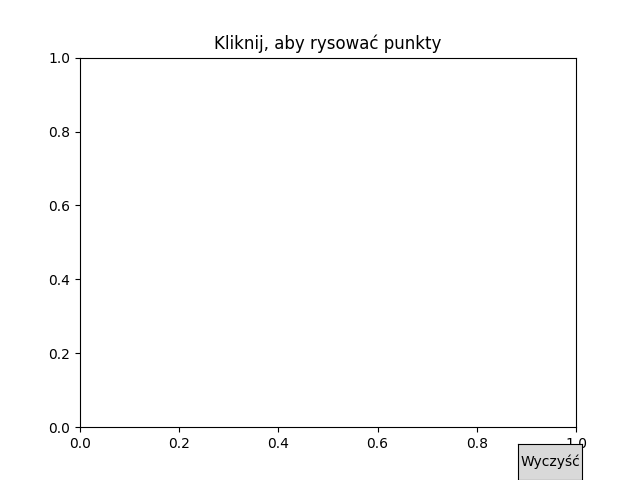

In [86]:
polygon = PolygonDrawer()

### Testowanie poprawności

In [87]:
points = test1
print(divide_and_conquer(points))

[Point(1, 1), Point(10, 1), Point(10, 10), Point(1, 10)]


### Algorytm wraz z wizualizacją

In [107]:
def divide_points_visual(points, first, last, visualizer, active_hulls):
    if last - first < 3:
        hull = set_hull(points, first, last)
        active_hulls.append(hull)
        visualizer.add_frame(points, active_hulls.copy(), [], [], None)
        return hull

    mid = (first + last) // 2

    visualizer.add_frame(points, active_hulls.copy(), [], [], None)

    left_hull = divide_points_visual(points, first, mid, visualizer, active_hulls)
    right_hull = divide_points_visual(points, mid + 1, last, visualizer, active_hulls)

    active_hulls.remove(left_hull)
    active_hulls.remove(right_hull)
    final_hull = merge_hulls(left_hull, right_hull)
    active_hulls.append(final_hull)

    visualizer.add_frame( points, active_hulls.copy(), [], [Segment(p1, p2) for p1, p2 in zip(final_hull, final_hull[1:] + final_hull[:1])], None)
    return final_hull


def divide_and_conquer_visual(points):
    visualizer = ConvexHullVisualizer()
    sorted_points = sorted(points, key=lambda point: (point.x, point.y))

    active_hulls = []
    visualizer.add_frame(sorted_points, [], [], [], None)

    divide_points_visual(sorted_points, 0, len(sorted_points) - 1, visualizer, active_hulls)
    display(visualizer.create_animation())


In [110]:
divide_and_conquer_visual(polygon.points)